# Word frequency

In [11]:
from wordcloud import WordCloud

In [7]:
import pandas as pd

df = pd.read_csv('../data/data.csv')   # adjust path if needed

In [8]:
df.columns


Index(['title', 'news_url', 'source_domain', 'tweet_num', 'label'], dtype='str')

In [9]:
from collections import Counter

words = " ".join(df['title']).split()
Counter(words).most_common(10)

[('and', 4450),
 ('to', 3765),
 ('the', 3712),
 ('of', 2783),
 ('in', 2439),
 ('a', 2163),
 ('on', 2156),
 ('The', 2101),
 ('for', 1761),
 ('Is', 1729)]

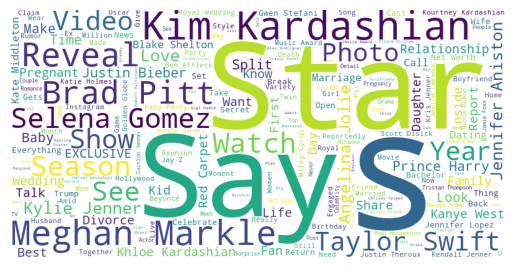

In [17]:
from wordcloud import WordCloud, STOPWORDS
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/data.csv')
df.rename(columns={'lable': 'label'}, inplace=True)
df = df.dropna(subset=['title'])

text = " ".join(df['title'])
fake_text = " ".join(df[df['label'] == 0]['title'])
real_text = " ".join(df[df['label'] == 1]['title'])

# Add custom stopwords
stopwords = set(STOPWORDS)
stopwords.update(['said', 'will', 'one', 'new'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords
).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

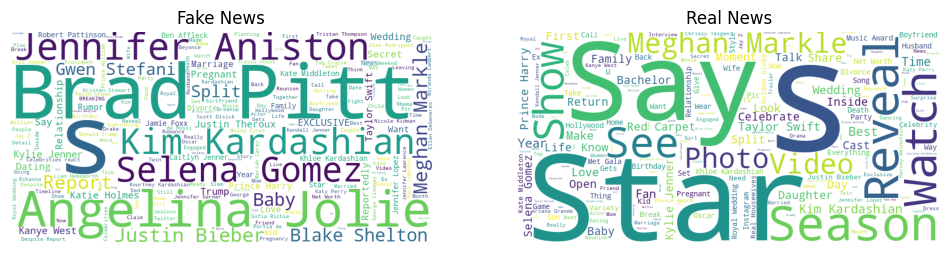

In [18]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

stopwords = set(STOPWORDS)
stopwords.update(['said', 'will', 'one', 'new'])

# Fake news
fake_text = " ".join(df[df['label'] == 0]['title'])
wc_fake = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(fake_text)

# Real news
real_text = " ".join(df[df['label'] == 1]['title'])
wc_real = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(real_text)

# Show both
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(wc_fake)
plt.title("Fake News")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wc_real)
plt.title("Real News")
plt.axis("off")

plt.show()

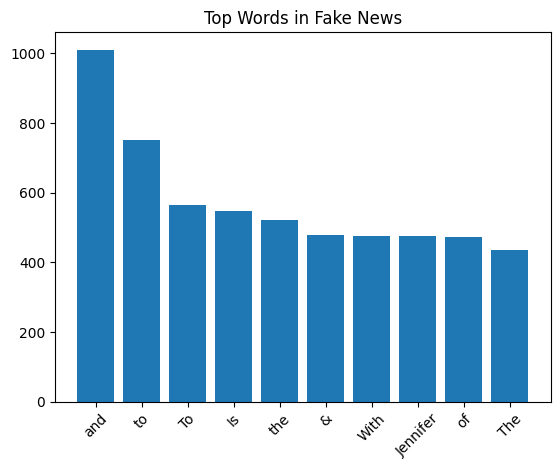

In [20]:
from collections import Counter

fake_words = Counter(fake_text.split()).most_common(10)

words, counts = zip(*fake_words)

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words in Fake News")
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


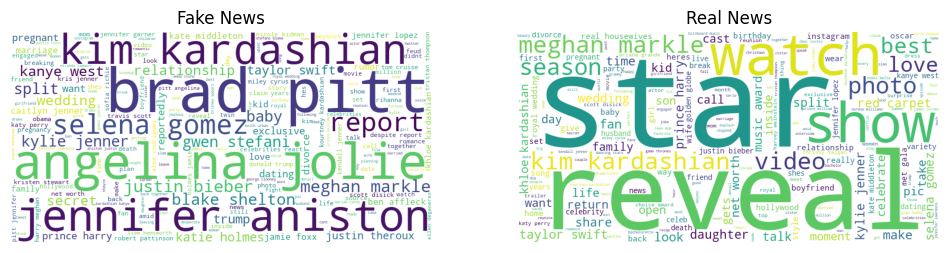

In [27]:
import nltk
nltk.download('stopwords')
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords as nltk_stopwords

# Combine stopwords
stopwords = set(STOPWORDS)
stopwords.update(nltk_stopwords.words('english'))

# Add custom unwanted words
stopwords.update(['said','say','says', 'will', 'one', 'new', 'year', 'see'])

# Clean function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return " ".join(words)

# Apply cleaning
df['clean_title'] = df['title'].apply(clean_text)

# Fake news
fake_text = " ".join(df[df['label'] == 0]['clean_title'])
wc_fake = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_text)

# Real news
real_text = " ".join(df[df['label'] == 1]['clean_title'])
wc_real = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(real_text)

# Show both
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(wc_fake)
plt.title("Fake News")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wc_real)
plt.title("Real News")
plt.axis("off")

plt.show()

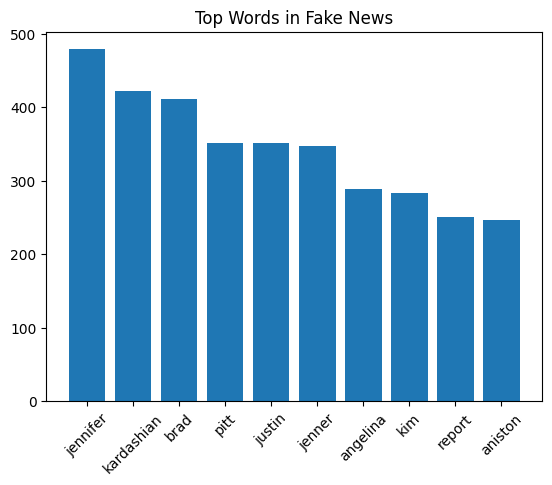

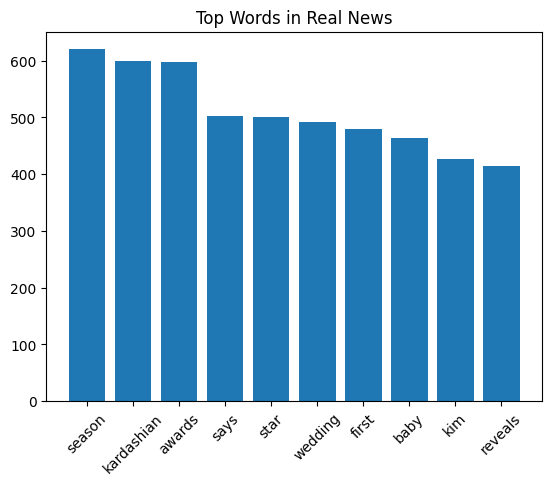

In [23]:
from collections import Counter

fake_words = Counter(fake_text.split()).most_common(10)
real_words = Counter(real_text.split()).most_common(10)

# Fake graph
words_f, counts_f = zip(*fake_words)

plt.figure()
plt.bar(words_f, counts_f)
plt.xticks(rotation=45)
plt.title("Top Words in Fake News")
plt.show()

# Real graph
words_r, counts_r = zip(*real_words)

plt.figure()
plt.bar(words_r, counts_r)
plt.xticks(rotation=45)
plt.title("Top Words in Real News")
plt.show()